In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df = pd.read_excel("have_fun.xlsx", sheet_name=1)
df.head()

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,3.8,82.0,0,0.0,0.0,3,19.1,1010.000000,2020-01-31 02:00:00,Ãåëåíäæèê
1,-3,70.0,0,0.0,0.0,3,24,981.900024,2025-02-28 09:00:00,Áëàãîâåùåíñê
2,-1.3,86.0,0,0.0,0.0,2,8.8,1021.200012,2022-01-03 02:00:00,Ãåëåíäæèê
3,19.299999,49.0,0,0.0,0.0,0,22.799999,1016.200012,2020-09-17 06:00:00,Ãåëåíäæèê
4,9.6,89.0,0,0.0,0.0,0,8.8,1024.400024,2025-04-16 05:00:00,Ãåëåíäæèê


Смотрим какие калонки с какими значениями есть в датасете

In [58]:
mask = df["city"].notna()
df.loc[mask, "city"] = df.loc[mask, "city"].str.encode("latin1").str.decode("cp1251")
df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values(by='ds')
df = df.rename(columns={"temperature_2m":"temp", "wind_speed_10m":"wind", "relative_humidity_2m":"humi", "surface_pressure": "press"})
df.head()

,temp,humi,precipitation,rain,snowfall,weathercode,wind,press,ds,city
250400,-1.8,85.0,0,0.0,0.0,3,23.5,1015.200012,2019-01-01,Санкт-Петербург
45450,4.5,94.0,0.3,0.3,0.0,51,5.5,1023.200012,2019-01-01,Геленджик
187698,-13.4,58.0,0,0.0,0.0,0,5.2,1025.500000,2019-01-01,Находка
5931,-13.7,56.0,0,0.0,0.0,3,12.6,1008.700012,2019-01-01,Благовещенск
125124,-6.5,92.0,0,0.0,0.0,3,10.8,1000.500000,2019-01-01,Москва


Переименовали столбцы для удобства. Также изменили кодировку столбца с городами, чтобы было понятно какие города есть

In [59]:
df["city"].value_counts()

city
Благовещенск       61690
Геленджик          61620
Находка            61387
Санкт-Петербург    61368
Москва             61364
Сочи               61364
Геленджикк           249
БЛАГОВЕЩЕНСК         245
Геленджи             242
благовещенск         239
Благовещенскк        231
геленджик            228
Благовещенс          226
ГЕЛЕНДЖИК            220
Сычи                   2
Мосва                  1
Счи                    1
Соч                    1
Name: count, dtype: int64

Смотрим список всех городов, чтобы понять надоли что-то править

In [60]:
df["city"]=df["city"].replace(["Соч", "Счи", "Сычи"], "Сочи")
df["city"] = df["city"].replace(["Мосва"], "Москва")
df["city"] = df["city"].replace(["ГЕЛЕНДЖИК", "геленджик", "Геленджи", "Геленджикк"], "Геленджик")
df["city"] = df["city"].replace(["БЛАГОВЕЩЕНСК", "благовещенск", "Благовещенскк", "Благовещенс"], "Благовещенск")
df["city"].value_counts()

city
Благовещенск       62631
Геленджик          62559
Находка            61387
Санкт-Петербург    61368
Сочи               61368
Москва             61365
Name: count, dtype: int64

Исправляем непрвавильное написание городов. В итоге получилось шесть городов

In [61]:
cols = ["temp", "humi", 'precipitation', 'rain', 'snowfall', "weathercode", "wind", "press"]
for c in cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df[~(df["humi"] > 100)]


Делаем так, чтобы во всех стобцах числа имени числовой формат вещественого числа. Также убираем нереалистичное значение влажности больше 100 процентов

In [62]:
df_Moscva = df[df["city"] == "Москва"]
df_Cochi = df[df["city"] == "Сочи"]
df_Gel = df[df["city"] == "Геленджик"]
df_Blag = df[df["city"] == "Благовещенск"]
df_StPt = df[df["city"] == "Санкт-Петербург"]
df_Naxod = df[df["city"] == "Находка"]
df_Moscva.drop(columns="city", inplace=True)
df_Cochi.drop(columns="city", inplace=True)
df_Gel.drop(columns="city", inplace=True)
df_Blag.drop(columns="city", inplace=True)
df_StPt.drop(columns="city", inplace=True)
df_Naxod.drop(columns="city", inplace=True)


C:\Users\Viktoria\AppData\Local\Temp\ipykernel_16680\1701749691.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Moscva.drop(columns="city", inplace=True)
C:\Users\Viktoria\AppData\Local\Temp\ipykernel_16680\1701749691.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Cochi.drop(columns="city", inplace=True)
C:\Users\Viktoria\AppData\Local\Temp\ipykernel_16680\1701749691.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df

Разделяем датасет на шесть по городам

In [63]:
cols = ["temp","wind", 'press', 'humi', "weathercode", 'rain', 'snowfall', 'precipitation']
for c in cols:
    df_Moscva[c] = df_Moscva[c].interpolate(method='linear')
    df_Moscva[c] = df_Moscva[c].ffill().bfill()

    df_Cochi[c] = df_Cochi[c].interpolate(method='linear')
    df_Cochi[c] = df_Cochi[c].ffill().bfill()

    df_Gel[c] = df_Gel[c].interpolate(method='linear')
    df_Gel[c] = df_Gel[c].ffill().bfill()

    df_Blag[c] = df_Blag[c].interpolate(method='linear')
    df_Blag[c] = df_Blag[c].ffill().bfill()
    
    df_StPt[c] = df_StPt[c].interpolate(method='linear')
    df_StPt[c] = df_StPt[c].ffill().bfill()

    df_Naxod[c] = df_Naxod[c].interpolate(method='linear')
    df_Naxod[c] = df_Naxod[c].ffill().bfill()

C:\Users\Viktoria\AppData\Local\Temp\ipykernel_16680\3402565153.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Moscva[c] = df_Moscva[c].interpolate(method='linear')
C:\Users\Viktoria\AppData\Local\Temp\ipykernel_16680\3402565153.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Moscva[c] = df_Moscva[c].ffill().bfill()
C:\Users\Viktoria\AppData\Local\Temp\ipykernel_16680\3402565153.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

С помощью линейной итрополяции заполняем все пустые ячеки в столбцах с числовыми значениями

In [64]:
df_Moscva["temp"].isna().sum()

0

Смотрим что пустоты не осталось

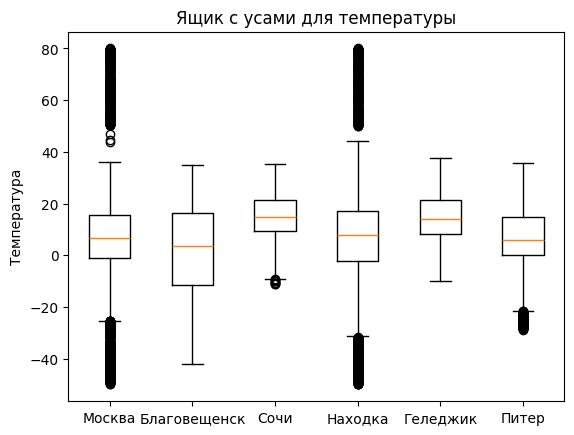

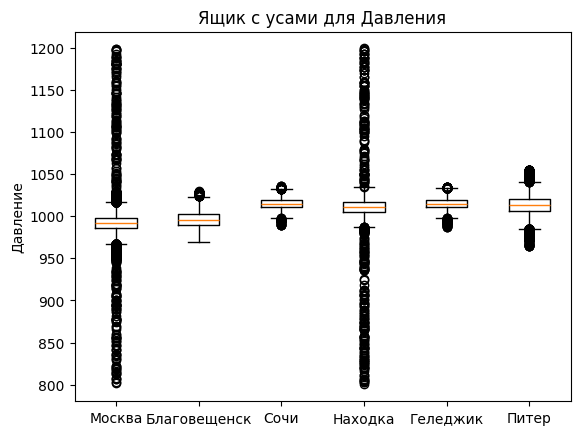

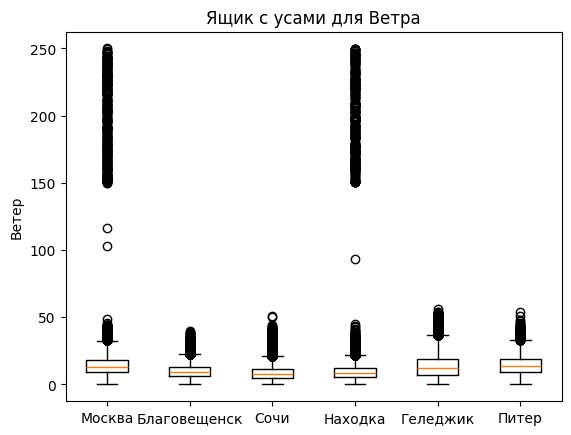

In [65]:
plt.boxplot([df_Moscva["temp"], df_Blag["temp"], df_Cochi["temp"], df_Naxod['temp'], df_Gel['temp'], df_StPt['temp']], labels=["Москва", "Благовещенск", "Сочи", "Находка", "Геледжик", "Питер"])
plt.title('Ящик с усами для температуры')
plt.ylabel('Температура')
plt.show()

plt.boxplot([df_Moscva["press"], df_Blag["press"], df_Cochi["press"], df_Naxod['press'], df_Gel['press'], df_StPt['press']], labels=["Москва", "Благовещенск", "Сочи", "Находка", "Геледжик", "Питер"])
plt.title('Ящик с усами для Давления')
plt.ylabel('Давление')
plt.show()

plt.boxplot([df_Moscva["wind"], df_Blag["wind"], df_Cochi["wind"], df_Naxod['wind'], df_Gel['wind'], df_StPt['wind']], labels=["Москва", "Благовещенск", "Сочи", "Находка", "Геледжик", "Питер"])
plt.title('Ящик с усами для Ветра')
plt.ylabel('Ветер')
plt.show()


Смотрим ящики с усами для некоторых столбцов,с тобы найти выбросы и аномальные значения

In [66]:
cols = ["wind", "temp", "press"]
for c in cols:
    Q1 = df_Moscva[c].quantile(0.25)
    Q3 = df_Moscva[c].quantile(0.75)
    IQR = Q3 - Q1

    bounds = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

    df_Moscva = df_Moscva[(df_Moscva[c].between(*bounds)) | df_Moscva[c].isna()]

    Q1 = df_Cochi[c].quantile(0.25)
    Q3 = df_Cochi[c].quantile(0.75)
    IQR = Q3 - Q1

    bounds = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

    df_Cochi = df_Cochi[(df_Cochi[c].between(*bounds)) | df_Cochi[c].isna()]

    Q1 = df_Naxod[c].quantile(0.25)
    Q3 = df_Naxod[c].quantile(0.75)
    IQR = Q3 - Q1

    bounds = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

    df_Naxod = df_Naxod[(df_Naxod[c].between(*bounds)) | df_Naxod[c].isna()]

    Q1 = df_StPt[c].quantile(0.25)
    Q3 = df_StPt[c].quantile(0.75)
    IQR = Q3 - Q1

    bounds = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

    df_StPt = df_StPt[(df_StPt[c].between(*bounds)) | df_StPt[c].isna()]

    Q1 = df_Blag[c].quantile(0.25)
    Q3 = df_Blag[c].quantile(0.75)
    IQR = Q3 - Q1

    bounds = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

    df_Blag = df_Blag[(df_Blag[c].between(*bounds)) | df_Blag[c].isna()]

    Q1 = df_Gel[c].quantile(0.25)
    Q3 = df_Gel[c].quantile(0.75)
    IQR = Q3 - Q1

    bounds = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

    df_Gel = df_Gel[(df_Gel[c].between(*bounds)) | df_Gel[c].isna()]


Убираем выбросы и анаомалии

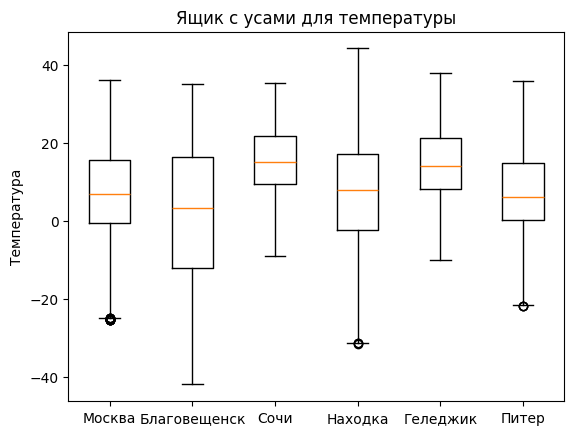

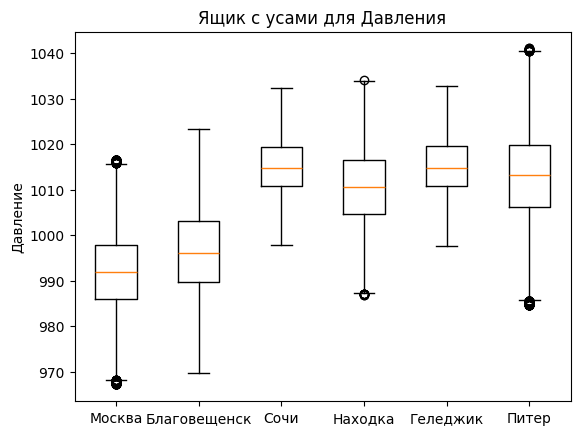

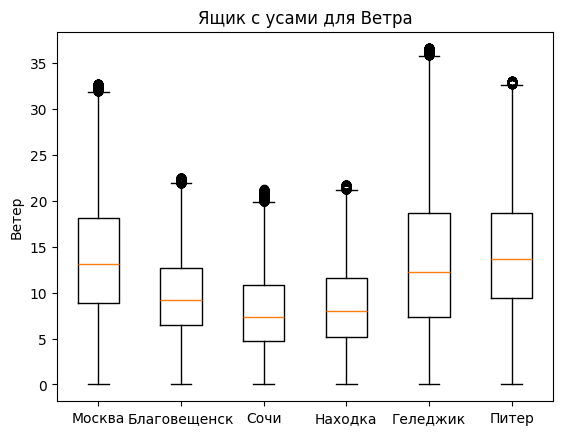

In [67]:
plt.boxplot([df_Moscva["temp"], df_Blag["temp"], df_Cochi["temp"], df_Naxod['temp'], df_Gel['temp'], df_StPt['temp']], labels=["Москва", "Благовещенск", "Сочи", "Находка", "Геледжик", "Питер"])
plt.title('Ящик с усами для температуры')
plt.ylabel('Температура')
plt.show()

plt.boxplot([df_Moscva["press"], df_Blag["press"], df_Cochi["press"], df_Naxod['press'], df_Gel['press'], df_StPt['press']], labels=["Москва", "Благовещенск", "Сочи", "Находка", "Геледжик", "Питер"])
plt.title('Ящик с усами для Давления')
plt.ylabel('Давление')
plt.show()

plt.boxplot([df_Moscva["wind"], df_Blag["wind"], df_Cochi["wind"], df_Naxod['wind'], df_Gel['wind'], df_StPt['wind']], labels=["Москва", "Благовещенск", "Сочи", "Находка", "Геледжик", "Питер"])
plt.title('Ящик с усами для Ветра')
plt.ylabel('Ветер')
plt.show()

Проверяем, что все правильно убралось

In [68]:
df_Moscva = df_Moscva.groupby(pd.Grouper(key="ds", freq="D")).mean()
df_Cochi = df_Cochi.groupby(pd.Grouper(key="ds", freq="D")).mean()
df_Blag = df_Blag.groupby(pd.Grouper(key="ds", freq="D")).mean()
df_Naxod = df_Naxod.groupby(pd.Grouper(key="ds", freq="D")).mean()
df_Gel = df_Gel.groupby(pd.Grouper(key="ds", freq="D")).mean()
df_StPt = df_StPt.groupby(pd.Grouper(key="ds", freq="D")).mean()
cols = ["temp","wind", 'press', 'humi', "weathercode", 'rain', 'snowfall', 'precipitation']
for c in cols:
    df_Moscva[c] = df_Moscva[c].interpolate(method='linear')
    df_Moscva[c] = df_Moscva[c].ffill().bfill()

    df_Cochi[c] = df_Cochi[c].interpolate(method='linear')
    df_Cochi[c] = df_Cochi[c].ffill().bfill()

    df_Gel[c] = df_Gel[c].interpolate(method='linear')
    df_Gel[c] = df_Gel[c].ffill().bfill()

    df_Blag[c] = df_Blag[c].interpolate(method='linear')
    df_Blag[c] = df_Blag[c].ffill().bfill()
    
    df_StPt[c] = df_StPt[c].interpolate(method='linear')
    df_StPt[c] = df_StPt[c].ffill().bfill()

    df_Naxod[c] = df_Naxod[c].interpolate(method='linear')
    df_Naxod[c] = df_Naxod[c].ffill().bfill()


Из датасетов по часам делаем датассеты по дням. Потом из-за того, что некотрых дней могло не быть в датасете по часам убираем NaN спомощью линейной интрополяции

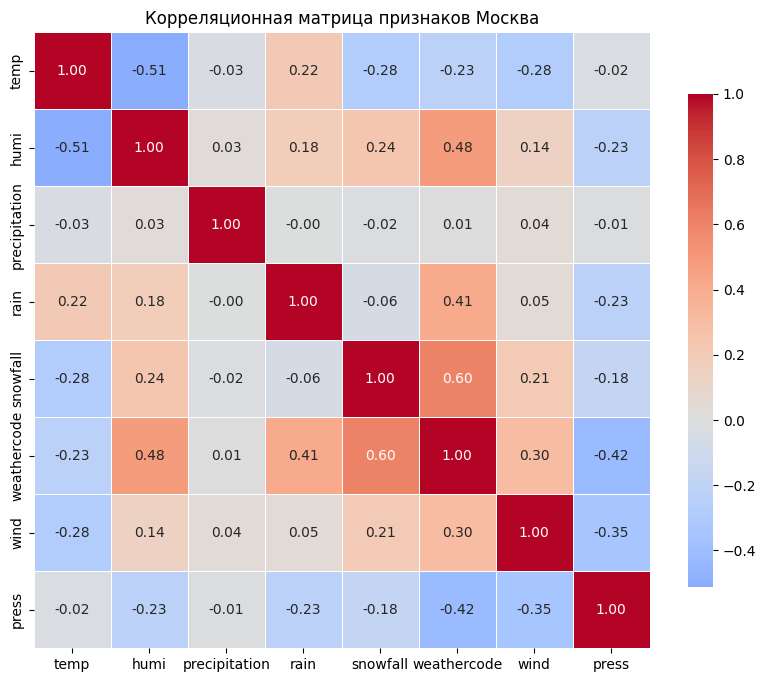

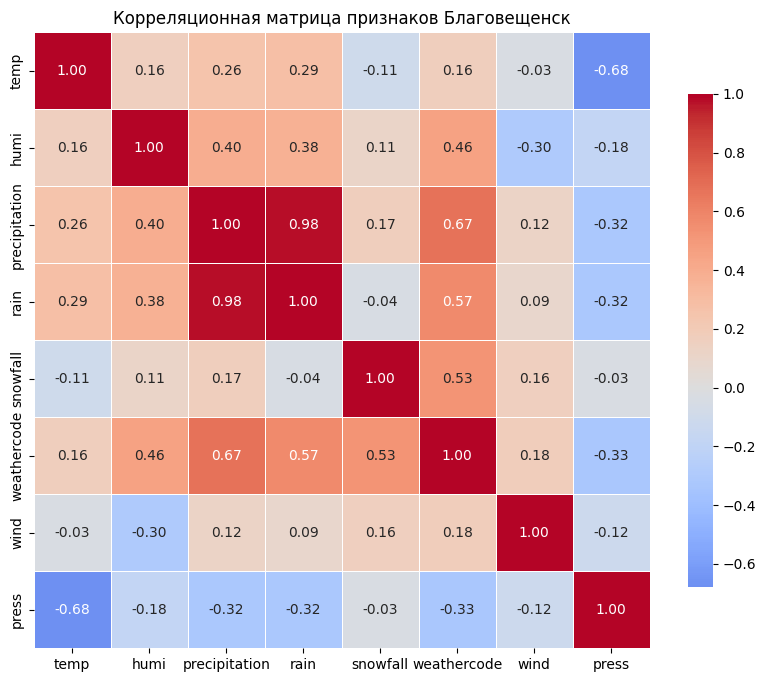

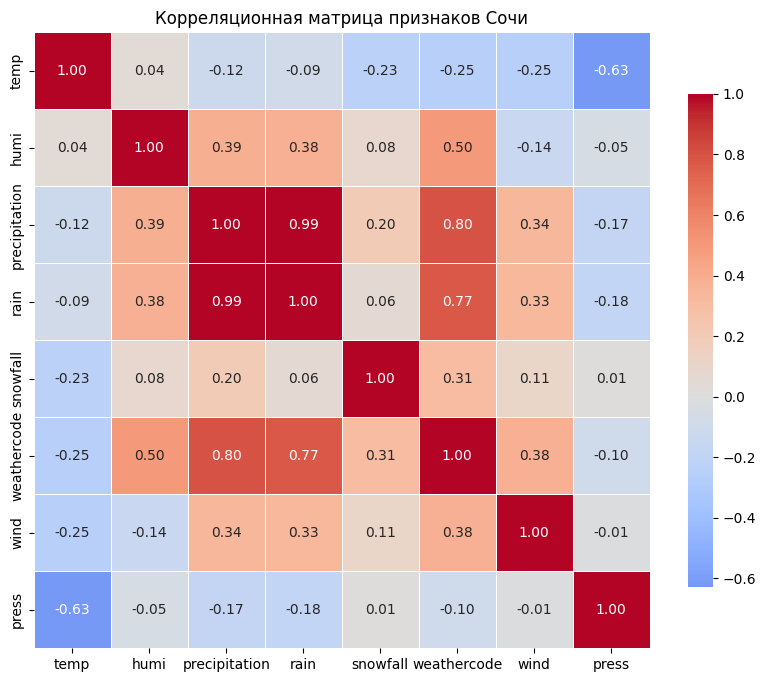

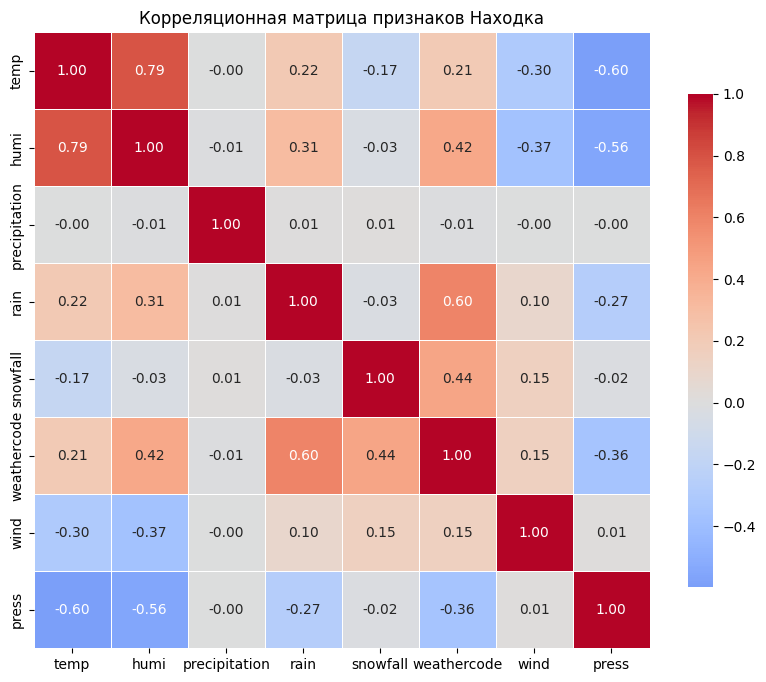

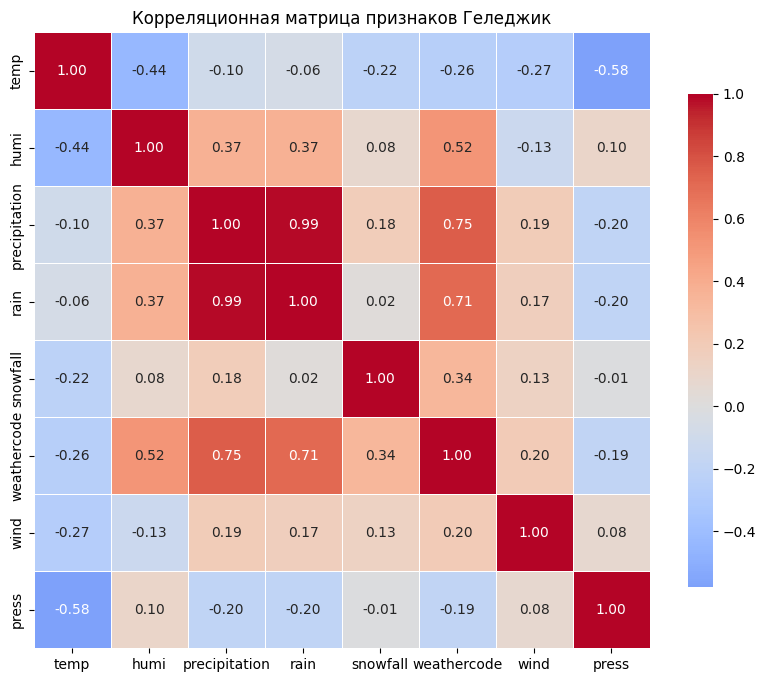

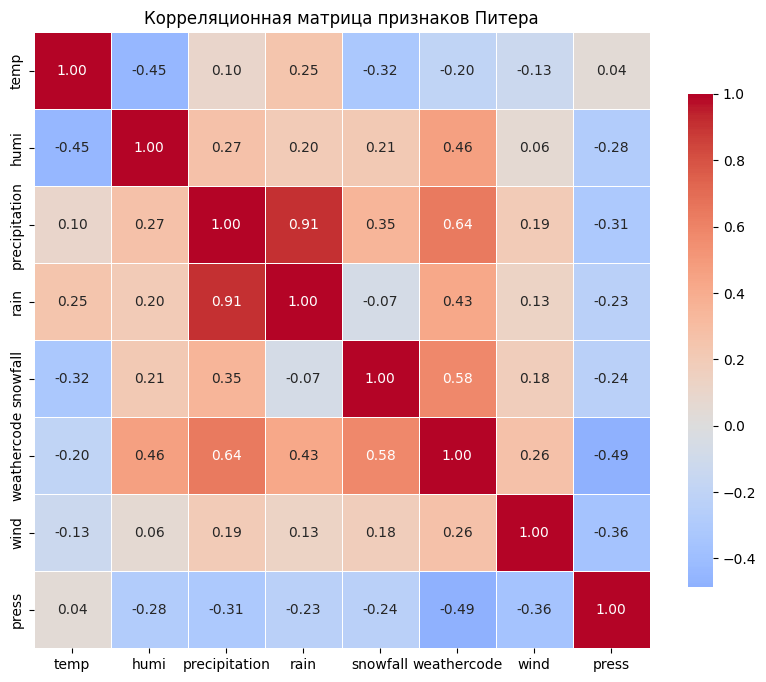

In [69]:
matrix_corr_M = df_Moscva.corr(numeric_only=True)
matrix_corr_C = df_Cochi.corr(numeric_only=True)
matrix_corr_B = df_Blag.corr(numeric_only=True)
matrix_corr_N = df_Naxod.corr(numeric_only=True)
matrix_corr_S = df_StPt.corr(numeric_only=True)
matrix_corr_G = df_Gel.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(matrix_corr_M, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков Москва')
plt.show()
plt.figure(figsize=(10, 8))
sns.heatmap(matrix_corr_B, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков Благовещенск')
plt.show()
plt.figure(figsize=(10, 8))
sns.heatmap(matrix_corr_C, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков Сочи')
plt.show()
plt.figure(figsize=(10, 8))
sns.heatmap(matrix_corr_N, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков Находка')
plt.show()
plt.figure(figsize=(10, 8))
sns.heatmap(matrix_corr_G, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков Геледжик')
plt.show()
plt.figure(figsize=(10, 8))
sns.heatmap(matrix_corr_S, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков Питера')
plt.show()

Смотрим корреляцию признаков

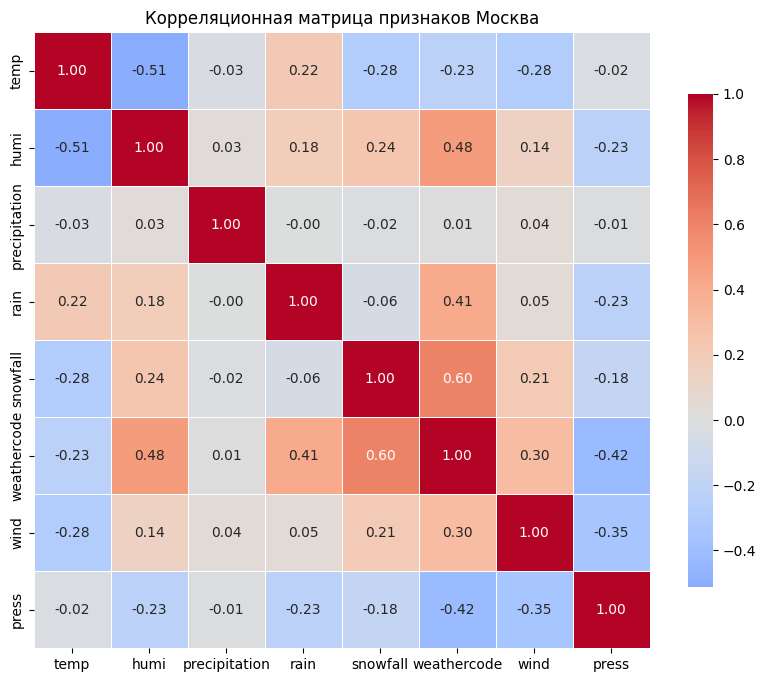

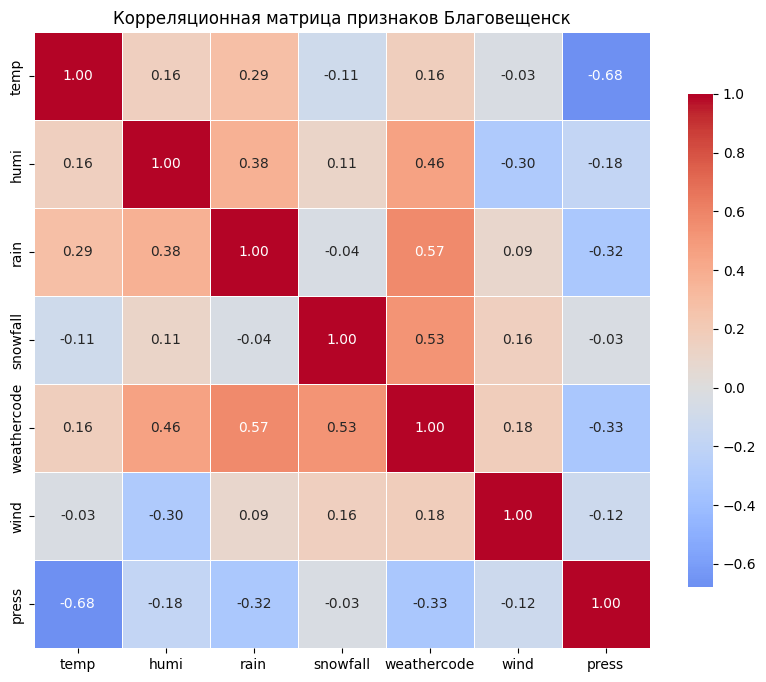

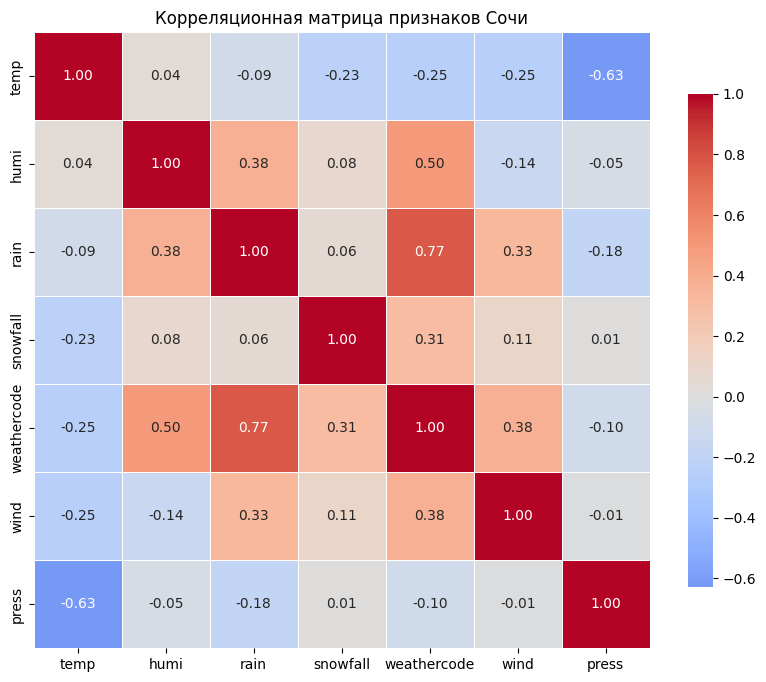

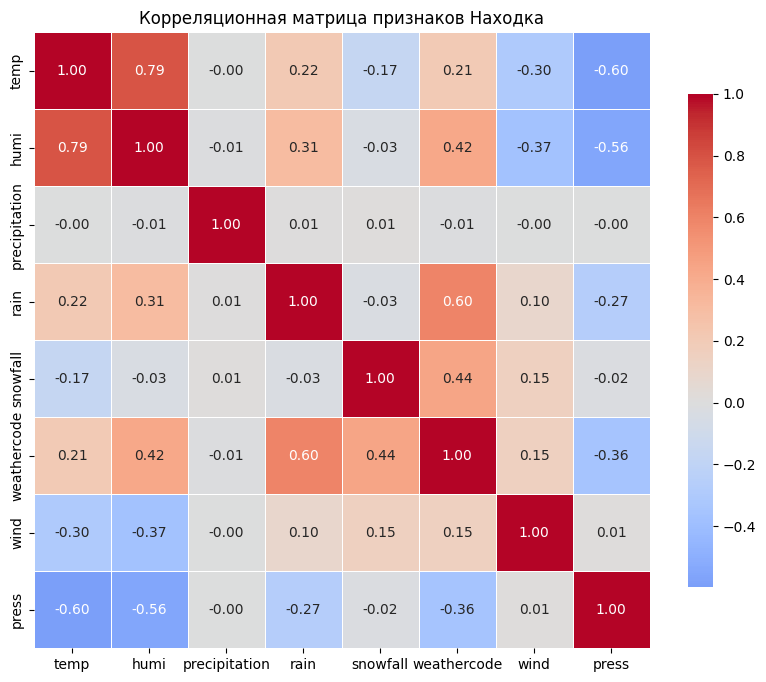

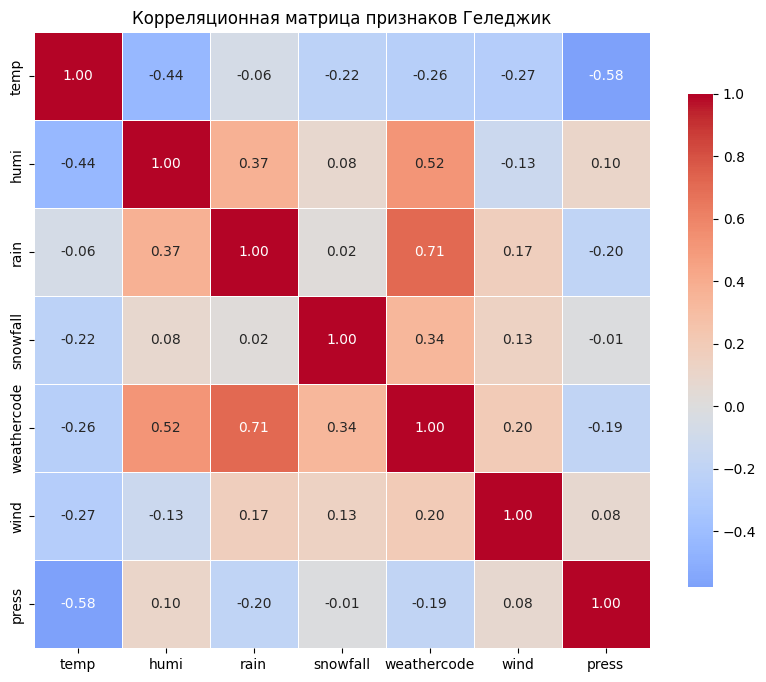

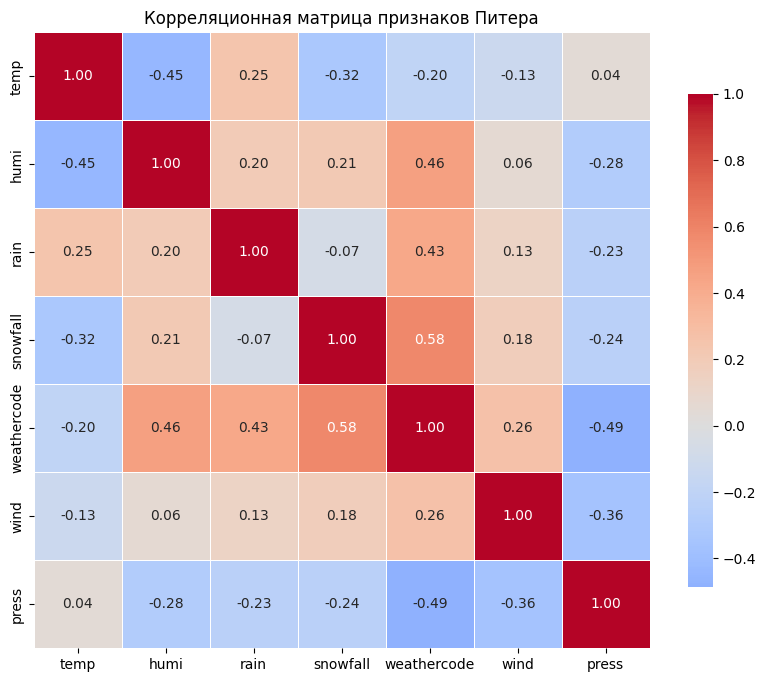

In [70]:
df_Gel.drop(columns='precipitation', inplace=True)
df_Cochi.drop(columns='precipitation', inplace=True)
df_Blag.drop(columns='precipitation', inplace=True)
df_StPt.drop(columns='precipitation', inplace=True)
matrix_corr_M = df_Moscva.corr(numeric_only=True)
matrix_corr_C = df_Cochi.corr(numeric_only=True)
matrix_corr_B = df_Blag.corr(numeric_only=True)
matrix_corr_N = df_Naxod.corr(numeric_only=True)
matrix_corr_S = df_StPt.corr(numeric_only=True)
matrix_corr_G = df_Gel.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(matrix_corr_M, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков Москва')
plt.show()
plt.figure(figsize=(10, 8))
sns.heatmap(matrix_corr_B, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков Благовещенск')
plt.show()
plt.figure(figsize=(10, 8))
sns.heatmap(matrix_corr_C, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков Сочи')
plt.show()
plt.figure(figsize=(10, 8))
sns.heatmap(matrix_corr_N, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков Находка')
plt.show()
plt.figure(figsize=(10, 8))
sns.heatmap(matrix_corr_G, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков Геледжик')
plt.show()
plt.figure(figsize=(10, 8))
sns.heatmap(matrix_corr_S, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков Питера')
plt.show()

Удалем сильно коррелирующие признаки и сново смотрим результат корреляции

In [74]:
df_Moscva.to_csv('Moscva.csv')
df_Gel.to_csv('Gel.csv')
df_Blag.to_csv('Blag.csv')
df_Naxod.to_csv('Naxod.csv')
df_Cochi.to_csv('Cochi.csv')
df_StPt.to_csv('StPt.csv')

Записываем датасеты по каждому городу в отдельные файлы для дальнейшей работы с каждым по отдельности